In [ ]:
# THIS MODULE IS SELF CODING

In [2]:
from typing import TypedDict, Annotated
from langchain_ollama import ChatOllama
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [3]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [4]:
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
memory = MemorySaver()

In [ ]:
import os
import sys
import subprocess
from pathlib import Path
from typing import Union, List
from langchain_core.tools import tool

# --- Configuration & Helpers ---

def get_project_root() -> Path:
    """Determine WORKING_DIR with reliable fallback logic."""
    try:
        if '__file__' in globals():
            return Path(__file__).parent.resolve()
        return Path.cwd().resolve()
    except Exception:
        return Path.cwd().resolve()

WORKING_DIR = get_project_root()

def is_safe_path(file_path: Union[str, Path]) -> bool:
    """Security check to prevent directory traversal."""
    try:
        path = Path(file_path)
        if not path.is_absolute():
            path = (WORKING_DIR / path).resolve()
        else:
            path = path.resolve()
        return WORKING_DIR in path.parents or path == WORKING_DIR
    except (ValueError, RuntimeError):
        return False

# --- Core Logic Functions (Plain Python) ---

def _read_file_logic(file_path: str) -> str:
    path = (WORKING_DIR / file_path).resolve()
    if not path.exists():
        return f"Error: File not found: {file_path}"
    try:
        return path.read_text(encoding='utf-8')
    except Exception as e:
        return f"Error reading file: {str(e)}"

def _write_file_logic(file_path: str, content: str) -> str:
    path = (WORKING_DIR / file_path).resolve()
    path.parent.mkdir(parents=True, exist_ok=True)
    try:
        path.write_text(content, encoding='utf-8')
        return f"Successfully wrote to {file_path}"
    except Exception as e:
        return f"Error writing file: {str(e)}"

# --- LangChain Tools ---

@tool
def list_files_in_workspace() -> str:
    """Lists all files in the workspace directory with relative paths starting with './'."""
    if not WORKING_DIR.exists():
        return f"Error: Workspace directory not found: {WORKING_DIR}"
    
    files = []
    for path in WORKING_DIR.rglob('*'):
        if path.is_file():
            rel_path = path.relative_to(WORKING_DIR)
            files.append(f"./{rel_path}")
            
    return "\n".join(sorted(files)) if files else "Workspace is empty."

@tool
def read_file(file_path: str) -> str:
    """Reads the content of a specific file. Accepts paths like './file.txt' or 'file.txt'."""
    if not is_safe_path(file_path):
        return f"Error: Access denied. Path '{file_path}' is outside workspace."
    return _read_file_logic(file_path)

@tool
def write_file(file_path: str, content: str) -> str:
    """Writes content to a file. Creates directories if needed."""
    if not is_safe_path(file_path):
        return f"Error: Access denied. Path '{file_path}' is outside workspace."
    return _write_file_logic(file_path, content)

@tool
def lint_code(file_path: str) -> str:
    """Checks for Python syntax errors in a file."""
    if not is_safe_path(file_path):
        return f"Error: Access denied."
    
    path = (WORKING_DIR / file_path).resolve()
    if not path.exists():
        return f"Error: File not found: {file_path}"
    
    try:
        source = path.read_text(encoding='utf-8')
        compile(source, str(path), 'exec')
        return "Syntax OK"
    except SyntaxError as e:
        return f"Syntax Error at line {e.lineno}: {e.msg}"
    except Exception as e:
        return f"Error: {str(e)}"

@tool
def execute_code(file_path: str) -> str:
    """Runs the Python file using the current interpreter and returns output."""
    if not is_safe_path(file_path):
        return f"Error: Access denied."
    
    path = (WORKING_DIR / file_path).resolve()
    if not path.exists():
        return f"Error: File not found: {file_path}"
    
    try:
        result = subprocess.run(
            [sys.executable, str(path)], 
            capture_output=True, 
            text=True, 
            timeout=30,
            cwd=str(WORKING_DIR)
        )
        if result.returncode == 0:
            return f"Success! Output:\n{result.stdout}"
        else:
            return f"Runtime Error:\n{result.stderr}"
    except subprocess.TimeoutExpired:
        return "Error: Execution timed out (30s)."
    except Exception as e:
        return f"Execution failed: {str(e)}"

@tool
def create_file_tool(file_path: str, content: str = "", overwrite: bool = False) -> str:
    """Creates a file with content. Returns success message or error."""
    if not is_safe_path(file_path):
        return f"Error: Access denied."
    
    path = (WORKING_DIR / file_path).resolve()
    if path.exists() and not overwrite:
        return f"Error: File already exists: {file_path}. Use overwrite=True to replace."
    
    # Calls the logic function directly, avoiding BaseTool attribute errors
    return _write_file_logic(file_path, content)

# --- Final Export ---

tools = [
    list_files_in_workspace,
    read_file,
    write_file,
    lint_code,
    execute_code,
    create_file_tool
]

print(f"✅ Loaded {len(tools)} tools. Root: {WORKING_DIR}")

✅ Loaded 6 tools. Root: D:\College\Projects\Web Development\Backend\Academics\rag-chatbot


In [ ]:
llm_with_tools = ChatOllama(model="gemma4:e2b", reasoning=False).bind_tools(tools)

In [26]:
def chatbot(state:State):
    return { "messages": llm_with_tools.invoke(state['messages']) }

In [27]:
builder = StateGraph(State)

builder.add_node("tools", ToolNode(tools))
builder.add_node("add_chatbot", chatbot)

builder.add_edge(START, "add_chatbot")
builder.add_conditional_edges("add_chatbot", tools_condition)
builder.add_edge("tools", "add_chatbot")

graph = builder.compile(checkpointer=memory)

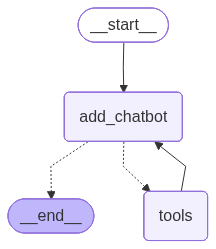

In [28]:
from IPython.display import display, Image
display(Image(graph.get_graph().draw_mermaid_png()))

In [33]:
from langchain_core.runnables import RunnableConfig

config2 : RunnableConfig = {
    'configurable' : {
        'thread_id' : '2'
    }
}

msg = "show me which files are available."
state = graph.invoke({ "messages" : [ { "role" : "user", "content": msg } ] }, config=config2)


print(state["messages"][-1].content)

Please provide a request.
